In [1]:
import numpy as np
from parameters import get_parameters, get_slider_params, calculate_derived_parameters
from model_run import run_model_dash
from global_func import reset_flags, reset_E, reset_HSS, reset_S
import math
import matplotlib.pyplot as plt
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

In [2]:
total_runs = 200
seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=total_runs)
MODEL = {
    "int_period": 36,
    "n_months": 36,
}
slider_params = get_slider_params()
results = []
for run in range(total_runs):
    base_seed = seeds[run]
    rng_param = np.random.default_rng(base_seed)
    b_param = get_parameters(rng = rng_param)
    b_param = calculate_derived_parameters(b_param)
    b_flags = reset_flags()
    b_HSS = reset_HSS(slider_params)
    b_S = reset_S(slider_params)
    b_E = reset_E()
    b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS
    })
    n_months = MODEL["n_months"]
    int_period = MODEL["int_period"]
    _, outcomes = run_model_dash(b_param, b_flags, n_months, int_period, base_seed=base_seed)

    outcomes['i_loc_grouped'] = np.where(outcomes['i_loc_new_v2'] == 0, 0,
                                         np.where(outcomes['i_loc_new_v2'] == 1, 1, 2))
    total_deaths = outcomes['i_mat_death'].sum()

    results.append({
        "p_death_SMO": outcomes[(outcomes['i_severe_new'] == 1) & (outcomes['i_loc_grouped'] == 2)]['i_mat_death'].mean(),
        "MMR_kenya": outcomes['i_mat_death'].mean() * 100000,
        "MMR_home":  outcomes[(outcomes['i_loc_grouped'] == 0)]['i_mat_death'].mean() * 100000,
        "MMR_l23":  outcomes[(outcomes['i_loc_grouped'] == 1)]['i_mat_death'].mean() * 100000,
        "MMR_l45":  outcomes[(outcomes['i_loc_grouped'] == 2)]['i_mat_death'].mean() * 100000,
         "p_death_aph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "aph")).sum() / total_deaths if total_deaths > 0 else 0,
        "p_death_pph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "pph")).sum() / total_deaths if total_deaths > 0 else 0,
        "p_death_eclampsia": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "eclampsia")).sum() / total_deaths if total_deaths > 0 else 0,
        "p_death_ol": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "ol")).sum() / total_deaths if total_deaths > 0 else 0,
        "p_death_sepsis": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "sepsis")).sum() / total_deaths if total_deaths > 0 else 0,
        "p_death_other": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "other")).sum() / total_deaths if total_deaths > 0 else 0,
    })

    # Convert to DataFrame and compute mean
df_results = pd.DataFrame(results).mean().to_dict()
#round 2 digits for each cell of df_results
df_results = {k: round(v, 3) for k, v in df_results.items()}
df_results

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


{'p_death_SMO': 0.021,
 'MMR_kenya': 217.183,
 'MMR_home': 482.647,
 'MMR_l23': 26.169,
 'MMR_l45': 106.719,
 'p_death_aph': 0.15,
 'p_death_pph': 0.265,
 'p_death_eclampsia': 0.232,
 'p_death_ol': 0.035,
 'p_death_sepsis': 0.168,
 'p_death_other': 0.15}

In [2]:
def find_min_runs(target_rse=0.01, max_runs=200, min_runs=10):
    """
    Determine the minimum number of simulation runs needed for stable outcomes
    based on convergence of relative standard error (RSE) over time.

    Args:
        target_rse: Maximum allowed relative standard error (e.g., 0.01 = 1%)
        max_runs: Maximum number of runs to test before giving up
        min_runs: Minimum number of runs required before checking for convergence

    Returns:
        min_runs: Recommended minimum number of runs
        convergence_data: Dictionary tracking all metrics' convergence (mean, stderr)
    """
    # Initialize metric names (no need for target values)
    metric_names = [
        "MMR_home", "MMR_l23", "MMR_l45",
        "p_death_aph", "p_death_pph", "p_death_eclampsia",
        "p_death_ol", "p_death_sepsis", "p_death_other"
    ]

    convergence_data = {k: {'values': [], 'means': [], 'stderrs': []} for k in metric_names}

    seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=max_runs)
    MODEL = {"int_period": 36, "n_months": 36}
    slider_params = get_slider_params()

    for run in range(max_runs):
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_param = calculate_derived_parameters(b_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        _, outcomes = run_model_dash(b_param, b_flags, MODEL["n_months"], MODEL["int_period"], base_seed=base_seed)

        outcomes['i_loc_grouped'] = np.where(outcomes['i_loc_new_v2'] == 0, 0,
                                             np.where(outcomes['i_loc_new_v2'] == 1, 1, 2))
        total_deaths = outcomes['i_mat_death'].sum()

        run_results = {
            "MMR_home": outcomes[(outcomes['i_loc_grouped'] == 0)]['i_mat_death'].mean() * 100000,
            "MMR_l23": outcomes[(outcomes['i_loc_grouped'] == 1)]['i_mat_death'].mean() * 100000,
            "MMR_l45": outcomes[(outcomes['i_loc_grouped'] == 2)]['i_mat_death'].mean() * 100000,
            "p_death_aph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "aph")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_pph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "pph")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_eclampsia": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "eclampsia")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_ol": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "ol")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_sepsis": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "sepsis")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_other": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "other")).sum() / total_deaths if total_deaths > 0 else 0,
        }

        all_metrics_converged = (run + 1 >= min_runs)
        for metric in metric_names:
            value = run_results[metric]
            convergence_data[metric]['values'].append(value)
            n = len(convergence_data[metric]['values'])

            stderr = np.std(convergence_data[metric]['values'], ddof=1) / np.sqrt(n) if n > 1 else 0.0
            mean = np.mean(convergence_data[metric]['values'])

            convergence_data[metric]['means'].append(mean)
            convergence_data[metric]['stderrs'].append(stderr)

            if mean != 0:
                rel_stderr = abs(stderr / mean)
            else:
                rel_stderr = 0.0

            if rel_stderr > target_rse:
                all_metrics_converged = False

        if all_metrics_converged:
            print(f"\n✅ Convergence achieved at {run + 1} runs (all metrics ≤ {target_rse * 100:.0f}% RSE)")
            return run + 1, convergence_data

    print(f"\n⚠️ Warning: Convergence not achieved after {max_runs} runs.")
    return max_runs, convergence_data

min_runs, conv_data = find_min_runs(target_rse=0.1, max_runs=500, min_runs=30)

# ✅ Convergence achieved at 201 runs (all metrics ≤ 10% RSE)

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



✅ Convergence achieved at 201 runs (all metrics ≤ 10% RSE)


Therefore, I use 200 runs for model calibration in this maternal death phase.

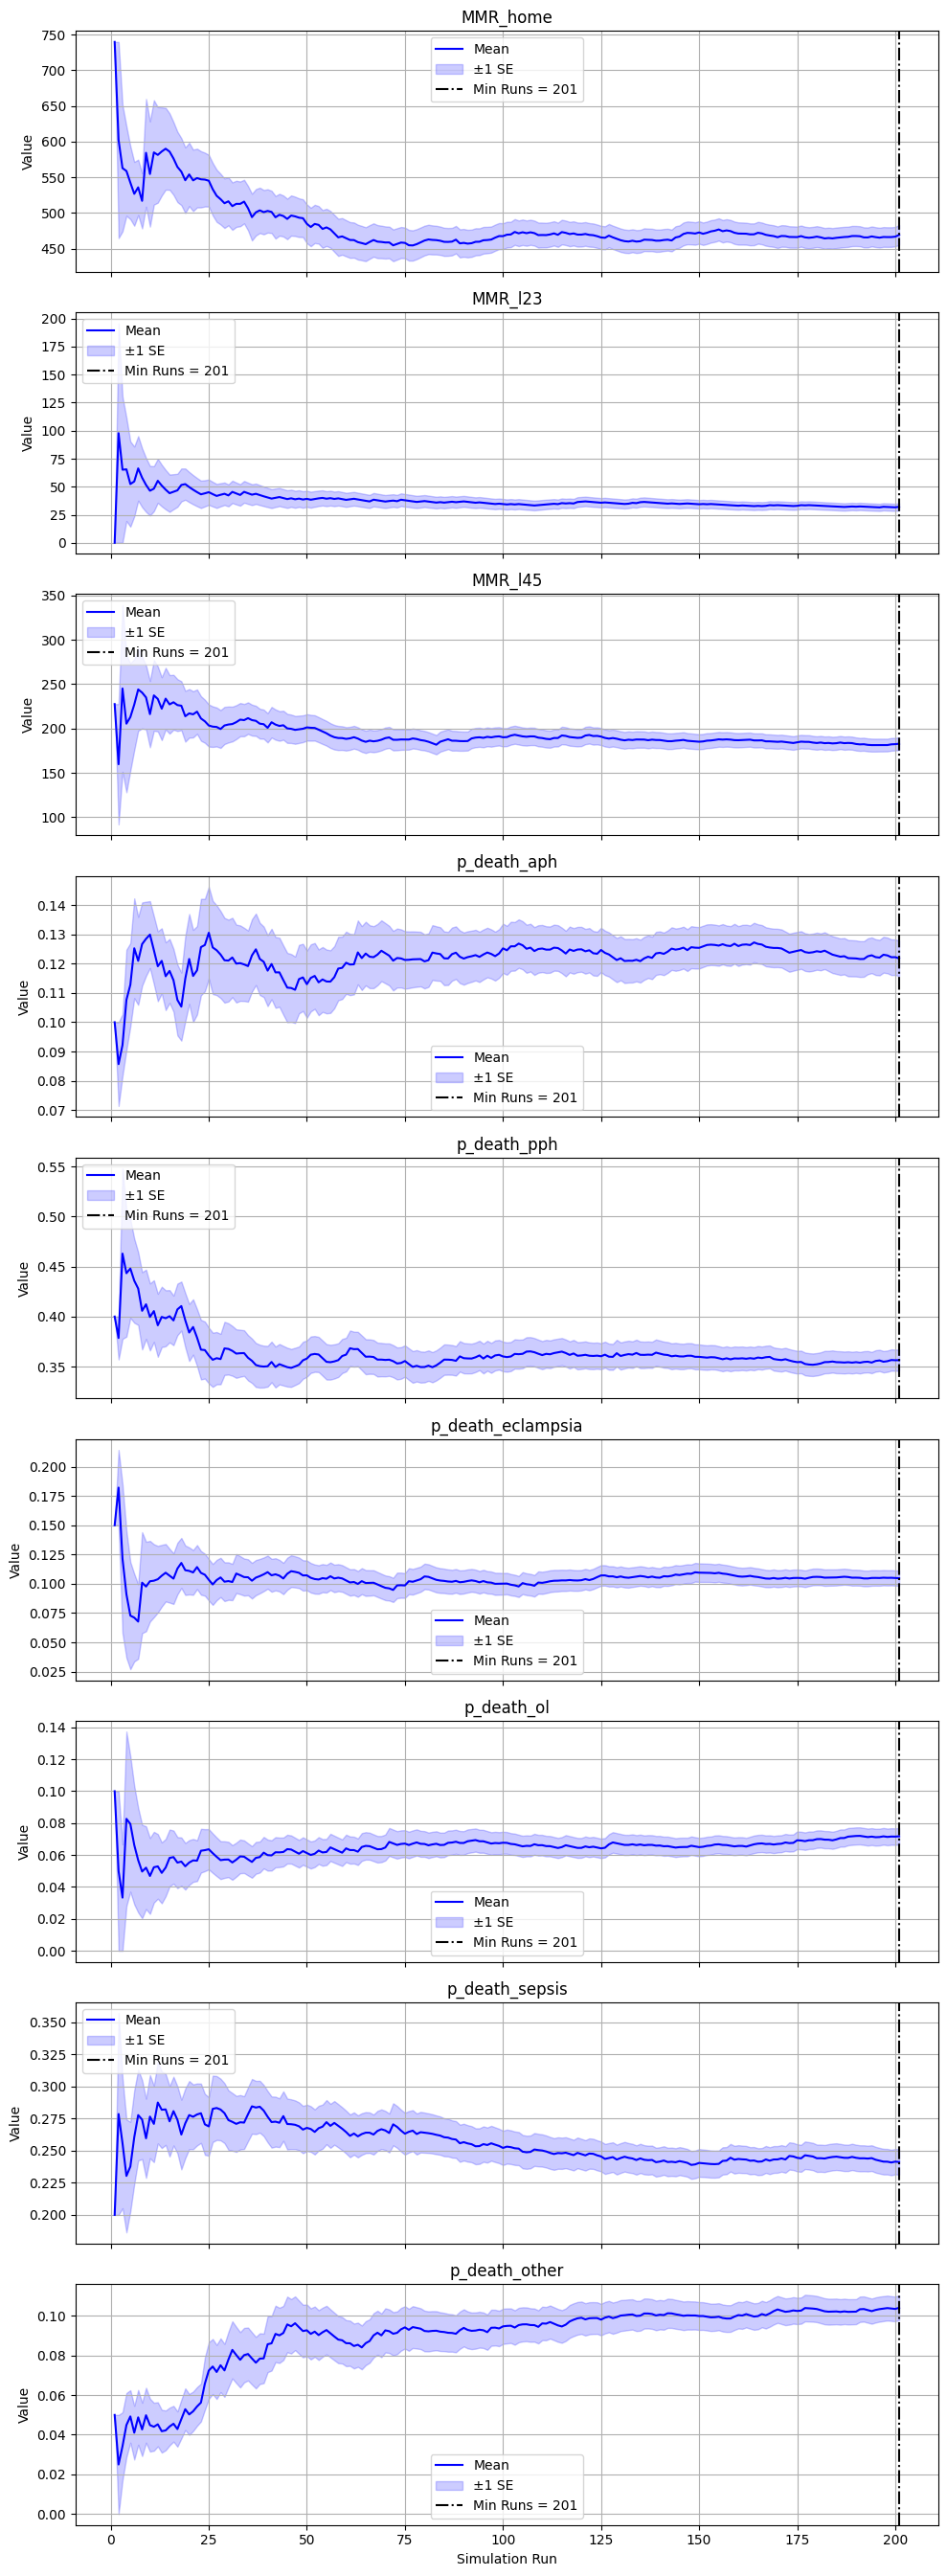

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence_curves(convergence_data, min_runs):
    """
    Plot convergence curves for each metric, showing mean and stderr bands over runs.
    """
    n_metrics = len(convergence_data)
    fig, axs = plt.subplots(n_metrics, 1, figsize=(10, 3 * n_metrics), sharex=True)

    if n_metrics == 1:
        axs = [axs]

    for ax, (metric, data) in zip(axs, convergence_data.items()):
        runs = list(range(1, len(data['means']) + 1))
        means = data['means']
        stderrs = data['stderrs']

        ax.plot(runs, means, label='Mean', color='blue')
        ax.fill_between(runs,
                        [m - s for m, s in zip(means, stderrs)],
                        [m + s for m, s in zip(means, stderrs)],
                        color='blue', alpha=0.2, label='±1 SE')

        ax.axvline(min_runs, color='black', linestyle='-.', label=f'Min Runs = {min_runs}')
        ax.set_title(metric)
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    axs[-1].set_xlabel('Simulation Run')
    plt.tight_layout()
    plt.show()
plot_convergence_curves(conv_data, min_runs)

In [2]:
# Define the parameter space for Bayesian Optimization
param_space = [
    Real(0.10, 0.30,         name='p_MM_home'),             #control "MMR_home"
    Real(1, 5,              name='weight_facility_mat'),             #control "MMR_l23" and "MMR_l45"
    Real(0.001, 0.01,       name='p_MM_others'),         #control MMR_other
    Real(0.10, 2.00,         name='MM_weight_pph'),    #control MMR_pph
    Real(0.10, 2.00,         name='MM_weight_sepsis'), #control MMR_sepsis
    Real(0.10, 2.00,         name='MM_weight_eclampsia'), #control MMR_eclampsia
    Real(0.10, 2.00,         name='MM_weight_ol'),      #control MMR_ol
    Real(0.10, 2.00,         name='MM_weight_aph'),    #control MMR_aph
]

def weighted_rmse(df_results, target_weights):
    weighted_errors = []

    for metric, (target, accepted_pct) in target_weights.items():
        simulated = df_results.get(metric, 0)
        error = (simulated - target)
        # Calculate absolute accepted error margin
        accepted_abs_error = target * (accepted_pct / 100)
        # Normalize error by accepted margin (0.5 = half of allowed error)
        normalized_error = error / accepted_abs_error
        weighted_errors.append(normalized_error**2)
    return math.sqrt(sum(weighted_errors) / len(weighted_errors))

# Calibration target values
target_weights = {
    # Key: (target_value, accepted_error_percentage)
    "MMR_home": (457, 10),
    "MMR_l23": (27, 10),
    "MMR_l45": (116, 10),

    "p_death_aph": (0.149, 10),
    "p_death_pph": (0.247, 10),
    "p_death_eclampsia": (0.258, 10),
    "p_death_ol": (0.035, 10),
    "p_death_sepsis": (0.165, 10),
    "p_death_other": (0.146, 10),
}

# Generate unique seeds for reproducibility
total_runs = 200
seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=total_runs)

# Objective function for Bayesian Optimization
@use_named_args(param_space)
def objective(**params):

    from parameters import get_parameters, get_slider_params
    from model_run import run_model_dash
    from global_func import reset_flags, reset_E, reset_HSS, reset_S

    MODEL = {
        "int_period": 36,
        "n_months": 36,
    }

    slider_params = get_slider_params()
    results = []

    for run in range(total_runs):
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        # Replace parameters with those to calibrate
        b_param['p_MM_home'] = params['p_MM_home']
        b_param['weight_facility_mat'] = params['weight_facility_mat']
        b_param['p_MM_others'] = params['p_MM_others']
        b_param['MM_weight_pph'] = params['MM_weight_pph']
        b_param['MM_weight_sepsis'] = params['MM_weight_sepsis']
        b_param['MM_weight_eclampsia'] = params['MM_weight_eclampsia']
        b_param['MM_weight_ol'] = params['MM_weight_ol']
        b_param['MM_weight_aph'] = params['MM_weight_aph']

        #update parameters
        b_param = calculate_derived_parameters(b_param)

        #run the model
        n_months = MODEL["n_months"]
        int_period = MODEL["int_period"]
        _, outcomes = run_model_dash(b_param, b_flags, n_months, int_period, base_seed=base_seed)

        # Calculate outcomes
        outcomes['i_loc_grouped'] = np.where(outcomes['i_loc_new_v2'] == 0, 0,
                                             np.where(outcomes['i_loc_new_v2'] == 1, 1, 2))
        total_deaths = outcomes['i_mat_death'].sum()


        results.append({
            "MMR_home": np.nan_to_num(outcomes[outcomes['i_loc_grouped'] == 0]['i_mat_death'].mean(), nan=0.0) * 100000,
            "MMR_l23": np.nan_to_num(outcomes[outcomes['i_loc_grouped'] == 1]['i_mat_death'].mean(), nan=0.0) * 100000,
            "MMR_l45": np.nan_to_num(outcomes[outcomes['i_loc_grouped'] == 2]['i_mat_death'].mean(), nan=0.0) * 100000,
            "p_death_aph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "aph")).sum() / total_deaths if total_deaths > 0 else 0,

            "p_death_pph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "pph")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_eclampsia": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "eclampsia")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_ol": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "ol")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_sepsis": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "sepsis")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_other": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "other")).sum() / total_deaths if total_deaths > 0 else 0,
        })


    # Convert to DataFrame and compute mean
    df_results = pd.DataFrame(results).mean().to_dict()

    # Add this line here for early stopping access
    objective.last_df_results = df_results

    # Compute RMSE
    rmse = weighted_rmse(df_results, target_weights)

    # Print current evaluation
    print("\n--- Calibration Iteration ---")
    print("Parameters:")
    for k, v in params.items():
        print(f"  {k:22s}: {v:.4f}")

    print("\nError Report (% of allowed tolerance):")
    for metric, (target, pct) in target_weights.items():
        simulated = df_results[metric]
        error_pct = 100 * (simulated - target) / target  # Actual error percentage
        tolerance_pct = pct  # Your predefined accepted error
        normalized = error_pct / tolerance_pct  # How much of allowed tolerance is used

        print(f"  {metric:20s}: {target:.4f} → {simulated:.4f} "
              f"({error_pct:+.1f}% / {tolerance_pct}% = {normalized:.2f}x allowed)")

    print(f"\nWeighted RMSE: {rmse:.3f} (Target: <1.0)")
    print("-----------------------------\n")
    return rmse

In [3]:
# Track RMSE history
class EarlyStopper:
    def __init__(self, threshold_rmse=1.0, max_patience=200):
        """
        Args:
            threshold_rmse: Target weighted RMSE (default 1.0 = all errors within tolerances)
            max_patience: How many iterations to wait without improvement before stopping
        """
        self.threshold_rmse = threshold_rmse
        self.max_patience = max_patience
        self.best_loss = float('inf')
        self.best_params = None
        self.best_df_results = None
        self.patience_counter = 0
        self.converged = False
        self.rmse_history = []  # Store history here instead

    def check_tolerance_violations(self, sim_results):
        """Returns list of metrics exceeding their allowed tolerances"""
        violations = []
        for metric, (target, accepted_pct) in target_weights.items():
            error_pct = 100 * abs(sim_results.get(metric, 0) - target) / target
            if error_pct > accepted_pct:
                violations.append(f"{metric} ({error_pct:.1f}% > {accepted_pct}%)")
        return violations

    def __call__(self, *args, **kwargs):
        loss = objective(*args, **kwargs)  # This now returns weighted RMSE
        self.rmse_history.append(loss)  # Track here

        # Track best results
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_params = args[0] if args else None
            self.best_df_results = getattr(objective, "last_df_results", {})
            self.patience_counter = 0  # Reset patience on improvement
        else:
            self.patience_counter += 1

        # Check stopping conditions
        if self.best_loss <= self.threshold_rmse:
            violations = self.check_tolerance_violations(self.best_df_results)
            if not violations:
                print(f"\n✅ Early stopping: All targets within tolerances (RMSE={self.best_loss:.3f} ≤ {self.threshold_rmse})")
                self.converged = True
                raise StopIteration
            else:
                print(f"\n⚠️ RMSE threshold met but tolerances violated: {', '.join(violations)}")

        if self.patience_counter >= self.max_patience:
            print(f"\n⏹️ Early stopping: No improvement for {self.max_patience} iterations (Best RMSE={self.best_loss:.3f})")
            raise StopIteration

        return loss

In [4]:
def save_results(best_params, best_loss, rmse_history, param_space, target_weights):
    """
    Save optimization results with enhanced reporting.

    Args:
        best_params: Optimized parameters
        best_loss: Best weighted RMSE achieved
        rmse_history: List of RMSE values over iterations
        param_space: Parameter search space
        target_weights: Dictionary of target tolerances
    """
    # Save best parameters
    param_names = [dim.name for dim in param_space]
    best_param_dict = dict(zip(param_names, best_params))
    best_param_dict["Weighted_RMSE"] = best_loss
    df_best = pd.DataFrame([best_param_dict])
    df_best.to_csv("best_parameters_death.csv", index=False)

    # Save full optimization history
    history_df = pd.DataFrame({
        "Iteration": range(1, len(rmse_history)+1),
        "Weighted_RMSE": rmse_history
    })
    history_df.to_csv("rmse_history_death.csv", index=False)

    # Enhanced plot with convergence threshold
    %matplotlib inline
    plt.figure(figsize=(12, 6))
    plt.plot(history_df["Iteration"], history_df["Weighted_RMSE"],
             marker='o', linestyle='-', label='Weighted RMSE')
    plt.axhline(y=1.0, color='r', linestyle='--',
                label='Tolerance Threshold (RMSE=1.0)')
    plt.xlabel("Iteration")
    plt.ylabel("Weighted RMSE")
    plt.title(f"Optimization Progress (Final RMSE: {best_loss:.3f})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("optimization_progress_death.png", dpi=300)
    plt.close()

    # Save target achievement report
    if hasattr(objective, "last_df_results"):
        target_report = []
        for metric, (target, pct) in target_weights.items():
            simulated = objective.last_df_results.get(metric, 0)
            error_pct = 100 * (simulated - target) / target
            target_report.append({
                "Metric": metric,
                "Target": target,
                "Simulated": simulated,
                "Error%": error_pct,
                "Tolerance%": pct,
                "Within_Tolerance": abs(error_pct) <= pct
            })

        pd.DataFrame(target_report).to_csv("target_achievement_report_death.csv", index=False)

In [5]:
def optimize_model():
    """
    Run Bayesian optimization with improved early stopping.
    Returns either optimization result or None if stopped early.
    """
    # Initialize with weighted RMSE threshold
    early_stopper = EarlyStopper(
        threshold_rmse=1.0,     # All errors within accepted tolerances
        max_patience=1000       # Stop if no improvement for 1000 iterations
    )

    try:
        result = gp_minimize(
            func=early_stopper,
            dimensions=param_space,
            n_calls=500,
            random_state=42,
            n_random_starts=80,
            verbose=True,
            n_jobs=-1  # Parallel execution
        )

        if early_stopper.converged:
            print("\n✅ Optimization converged successfully!")
        else:
            print("\n⚠️ Optimization completed but did not fully converge")

        print(f"Best Weighted RMSE: {result.fun:.3f}")
        save_results(result.x, result.fun, early_stopper.rmse_history, param_space, target_weights)
        return result

    except StopIteration:
        print("\n⏹️ Optimization stopped by early stopping criteria")
        print(f"Best Weighted RMSE achieved: {early_stopper.best_loss:.3f}")

        if early_stopper.best_params is not None:
            print("\nBest Parameters:")
            for name, val in zip([d.name for d in param_space], early_stopper.best_params):
                print(f"  {name:22s}: {val:.4f}")

            save_results(
                early_stopper.best_params,
                early_stopper.best_loss,
                early_stopper.rmse_history,
                param_space,
                target_weights
            )

        return None

# Run the optimization
if __name__ == "__main__":
    final_result = optimize_model()

    # Additional post-optimization analysis
    if final_result is not None or hasattr(objective, "last_df_results"):
        print("\nTarget Achievement Summary:")
        for metric, (target, pct) in target_weights.items():
            simulated = objective.last_df_results.get(metric, 0)
            status = "✓" if abs(100*(simulated-target)/target) <= pct else "✗"
            print(f"  {status} {metric:20s}: {simulated:.4f} (Target: {target:.4f} ±{pct}%)")

Iteration No: 1 started. Evaluating function at random point.


/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



--- Calibration Iteration ---
Parameters:
  p_MM_home             : 0.2593
  weight_facility_mat   : 1.7337
  p_MM_others           : 0.0080
  MM_weight_pph         : 1.2340
  MM_weight_sepsis      : 0.9471
  MM_weight_eclampsia   : 0.2900
  MM_weight_ol          : 0.9726
  MM_weight_aph         : 0.7340

Error Report (% of allowed tolerance):
  MMR_home            : 457.0000 → 827.1672 (+81.0% / 10% = 8.10x allowed)
  MMR_l23             : 27.0000 → 21.1066 (-21.8% / 10% = -2.18x allowed)
  MMR_l45             : 116.0000 → 67.7097 (-41.6% / 10% = -4.16x allowed)
  p_death_aph         : 0.1490 → 0.0600 (-59.7% / 10% = -5.97x allowed)
  p_death_pph         : 0.2470 → 0.1455 (-41.1% / 10% = -4.11x allowed)
  p_death_eclampsia   : 0.2580 → 0.0351 (-86.4% / 10% = -8.64x allowed)
  p_death_ol          : 0.0350 → 0.2153 (+515.1% / 10% = 51.51x allowed)
  p_death_sepsis      : 0.1650 → 0.2965 (+79.7% / 10% = 7.97x allowed)
  p_death_other       : 0.1460 → 0.2477 (+69.6% / 10% = 6.96x allowed

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



--- Calibration Iteration ---
Parameters:
  p_MM_home             : 0.1286
  weight_facility_mat   : 3.6036
  p_MM_others           : 0.0015
  MM_weight_pph         : 1.4718
  MM_weight_sepsis      : 1.8833
  MM_weight_eclampsia   : 0.1015
  MM_weight_ol          : 1.9852
  MM_weight_aph         : 1.2732

Error Report (% of allowed tolerance):
  MMR_home            : 457.0000 → 563.5754 (+23.3% / 10% = 2.33x allowed)
  MMR_l23             : 27.0000 → 28.8965 (+7.0% / 10% = 0.70x allowed)
  MMR_l45             : 116.0000 → 195.5127 (+68.5% / 10% = 6.85x allowed)
  p_death_aph         : 0.1490 → 0.0692 (-53.6% / 10% = -5.36x allowed)
  p_death_pph         : 0.2470 → 0.1441 (-41.7% / 10% = -4.17x allowed)
  p_death_eclampsia   : 0.2580 → 0.0078 (-97.0% / 10% = -9.70x allowed)
  p_death_ol          : 0.0350 → 0.2996 (+756.1% / 10% = 75.61x allowed)
  p_death_sepsis      : 0.1650 → 0.4525 (+174.3% / 10% = 17.43x allowed)
  p_death_other       : 0.1460 → 0.0267 (-81.7% / 10% = -8.17x allowe

...


--- Calibration Iteration ---
Parameters:
  p_MM_home             : 0.1413
  weight_facility_mat   : 2.6678
  p_MM_others           : 0.0053
  MM_weight_pph         : 2.0000
  MM_weight_sepsis      : 0.4329
  MM_weight_eclampsia   : 2.0000
  MM_weight_ol          : 0.1808
  MM_weight_aph         : 2.0000

Error Report (% of allowed tolerance):
  MMR_home            : 457.0000 → 459.0863 (+0.5% / 10% = 0.05x allowed)
  MMR_l23             : 27.0000 → 25.5065 (-5.5% / 10% = -0.55x allowed)
  MMR_l45             : 116.0000 → 105.1334 (-9.4% / 10% = -0.94x allowed)
  p_death_aph         : 0.1490 → 0.1550 (+4.0% / 10% = 0.40x allowed)
  p_death_pph         : 0.2470 → 0.2723 (+10.2% / 10% = 1.02x allowed)
  p_death_eclampsia   : 0.2580 → 0.2365 (-8.3% / 10% = -0.83x allowed)
  p_death_ol          : 0.0350 → 0.0340 (-2.8% / 10% = -0.28x allowed)
  p_death_sepsis      : 0.1650 → 0.1523 (-7.7% / 10% = -0.77x allowed)
  p_death_other       : 0.1460 → 0.1499 (+2.7% / 10% = 0.27x allowed)

Weight

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



--- Calibration Iteration ---
Parameters:
  p_MM_home             : 0.1431
  weight_facility_mat   : 2.6639
  p_MM_others           : 0.0053
  MM_weight_pph         : 2.0000
  MM_weight_sepsis      : 0.4715
  MM_weight_eclampsia   : 2.0000
  MM_weight_ol          : 0.1865
  MM_weight_aph         : 2.0000

Error Report (% of allowed tolerance):
  MMR_home            : 457.0000 → 476.4687 (+4.3% / 10% = 0.43x allowed)
  MMR_l23             : 27.0000 → 25.8423 (-4.3% / 10% = -0.43x allowed)
  MMR_l45             : 116.0000 → 106.2733 (-8.4% / 10% = -0.84x allowed)
  p_death_aph         : 0.1490 → 0.1499 (+0.6% / 10% = 0.06x allowed)
  p_death_pph         : 0.2470 → 0.2662 (+7.8% / 10% = 0.78x allowed)
  p_death_eclampsia   : 0.2580 → 0.2320 (-10.1% / 10% = -1.01x allowed)
  p_death_ol          : 0.0350 → 0.0354 (+1.2% / 10% = 0.12x allowed)
  p_death_sepsis      : 0.1650 → 0.1662 (+0.7% / 10% = 0.07x allowed)
  p_death_other       : 0.1460 → 0.1504 (+3.0% / 10% = 0.30x allowed)

Weighted

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



--- Calibration Iteration ---
Parameters:
  p_MM_home             : 0.1456
  weight_facility_mat   : 2.6661
  p_MM_others           : 0.0053
  MM_weight_pph         : 2.0000
  MM_weight_sepsis      : 0.4760
  MM_weight_eclampsia   : 2.0000
  MM_weight_ol          : 0.1855
  MM_weight_aph         : 2.0000

Error Report (% of allowed tolerance):
  MMR_home            : 457.0000 → 481.6028 (+5.4% / 10% = 0.54x allowed)
  MMR_l23             : 27.0000 → 26.1686 (-3.1% / 10% = -0.31x allowed)
  MMR_l45             : 116.0000 → 106.7192 (-8.0% / 10% = -0.80x allowed)
  p_death_aph         : 0.1490 → 0.1502 (+0.8% / 10% = 0.08x allowed)
  p_death_pph         : 0.2470 → 0.2650 (+7.3% / 10% = 0.73x allowed)
  p_death_eclampsia   : 0.2580 → 0.2323 (-10.0% / 10% = -1.00x allowed)
  p_death_ol          : 0.0350 → 0.0350 (+0.1% / 10% = 0.01x allowed)
  p_death_sepsis      : 0.1650 → 0.1689 (+2.4% / 10% = 0.24x allowed)
  p_death_other       : 0.1460 → 0.1484 (+1.7% / 10% = 0.17x allowed)

Weighted

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV if needed
rmse_df = pd.read_csv("RMSE_History_death.csv")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rmse_df['Iteration'], rmse_df['Weighted_RMSE'], marker='o', label='Weighted RMSE')
plt.axhline(y=1.0, color='red', linestyle='--', label='Tolerance Threshold (RMSE=1.0)')

# Add labels and title
final_rmse = rmse_df['Weighted_RMSE'].iloc[-1]
plt.title(f"Optimization Progress (Final RMSE: {final_rmse:.3f})")
plt.xlabel("Iteration")
plt.ylabel("Weighted RMSE")
plt.legend()
plt.grid(True)

# Save the plot
plt.savefig("rmse_death.png", dpi=300)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
# ✅ Early stopping: All targets within tolerances (RMSE=0.541 ≤ 1.0)
#
# ⏹️ Optimization stopped by early stopping criteria
# Best Weighted RMSE achieved: 0.541
#
# Best Parameters:
#   p_MM_home             : 0.1456
#   weight_facility_mat   : 2.6661
#   p_MM_others           : 0.0053
#   MM_weight_pph         : 2.0000
#   MM_weight_sepsis      : 0.4760
#   MM_weight_eclampsia   : 2.0000
#   MM_weight_ol          : 0.1855
#   MM_weight_aph         : 2.0000
#
# Target Achievement Summary:
#   ✓ MMR_home            : 481.6028 (Target: 457.0000 ±10%)
#   ✓ MMR_l23             : 26.1686 (Target: 27.0000 ±10%)
#   ✓ MMR_l45             : 106.7192 (Target: 116.0000 ±10%)
#   ✓ p_death_aph         : 0.1502 (Target: 0.1490 ±10%)
#   ✓ p_death_pph         : 0.2650 (Target: 0.2470 ±10%)
#   ✓ p_death_eclampsia   : 0.2323 (Target: 0.2580 ±10%)
#   ✓ p_death_ol          : 0.0350 (Target: 0.0350 ±10%)
#   ✓ p_death_sepsis      : 0.1689 (Target: 0.1650 ±10%)
#   ✓ p_death_other       : 0.1484 (Target: 0.1460 ±10%)